In [1]:
#=== COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "dplant227"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The objective of this experiment is to determine the optimal combination of ingredients: Protein, Salsa and Potatoes, for Buster's Breakfast Burritos that maximizes customer satisfaction.

2. State the outcome variable and how it was measured.

The outcome variable is Customer Satisfaction. This is a nominal discrete variable rated on a scale from 1 to 10, with 1 being terrible to 10 being amazing.

3. State the independent variables. What lurking variables may be present?

The independent variables are Protein with 3 levels, Salsa with 2 levels, Potatoes with 2 levels. These are ordinal values. Potential lurking variables could be the time of day, baseline hunger, the size of the burrito, the weight of the participant, spice tolerances, temperature of the burrito.

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

A full factorial design would be preferred as the number of total treatment levels is small:12. With 10 replicated the total sample size is 120 which works well. It also has one factor with 3 levels which is not in the standard fractional factorial design structure. A full factorial design allows us to estimate all main effects and interactions without aliasing.

5. State all sets of statistical hypotheses.

Let $\mu$ represent the true mean satisfaction score.

* **Main Effects:**
  * **Protein:** $H_0$: $\mu_{Bacon} = \mu_{Sausage} = \mu_{Chorizo}$ vs. $H_a$: At least one protein mean is different.
  * **Salsa:** $H_0$: $\mu_{Mild} = \mu_{Hot}$ vs. $H_a$: $\mu_{Mild} \neq \mu_{Hot}$.
  * **Potatoes:** $H_0$: $\mu_{Yes} = \mu_{No}$ vs. $H_a$: $\mu_{Yes} \neq \mu_{No}$.
* **Two-Way Interactions:**
  * $H_0$: There is no interaction between [Protein and Salsa / Protein and Potatoes / Salsa and Potatoes].
  * $H_a$: There is a significant interaction between the respective pairs.
* **Three-Way Interaction:**
  * $H_0$: There is no three-way interaction between Protein, Salsa, and Potatoes.
  * $H_a$: There is a significant three-way interaction.


6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


Question 6: Exploratory Data Analysis
['Protein', 'Salsa', 'Potatoes', 'Satisfaction']
              count unique    top freq      mean       std  min  25%  50%  \
Protein         120      3  Bacon   40       NaN       NaN  NaN  NaN  NaN   
Salsa           120      2   Mild   60       NaN       NaN  NaN  NaN  NaN   
Potatoes        120      2    Yes   60       NaN       NaN  NaN  NaN  NaN   
Satisfaction  120.0    NaN    NaN  NaN  6.543333  1.181562  3.7  5.6  6.7   

              75%  max  
Protein       NaN  NaN  
Salsa         NaN  NaN  
Potatoes      NaN  NaN  
Satisfaction  7.4  8.9  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Protein       120 non-null    object 
 1   Salsa         120 non-null    object 
 2   Potatoes      120 non-null    object 
 3   Satisfaction  120 non-null    float64
dtypes: float64(1), object(3)
memory usa

,Protein,mean,std
0,Bacon,6.8500,0.928467
1,Chorizo,7.0075,1.167374
2,Sausage,5.7725,1.052710



Satisfaction by Salsa:


,Salsa,mean,std
0,Hot,6.070000,1.116031
1,Mild,7.016667,1.055762



Satisfaction by Potatoes:


,Potatoes,mean,std
0,No,6.335000,1.227071
1,Yes,6.751667,1.105378


/tmp/ipykernel_6037/2098385555.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipykernel_6037/2098385555.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipykernel_6037/2098385555.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



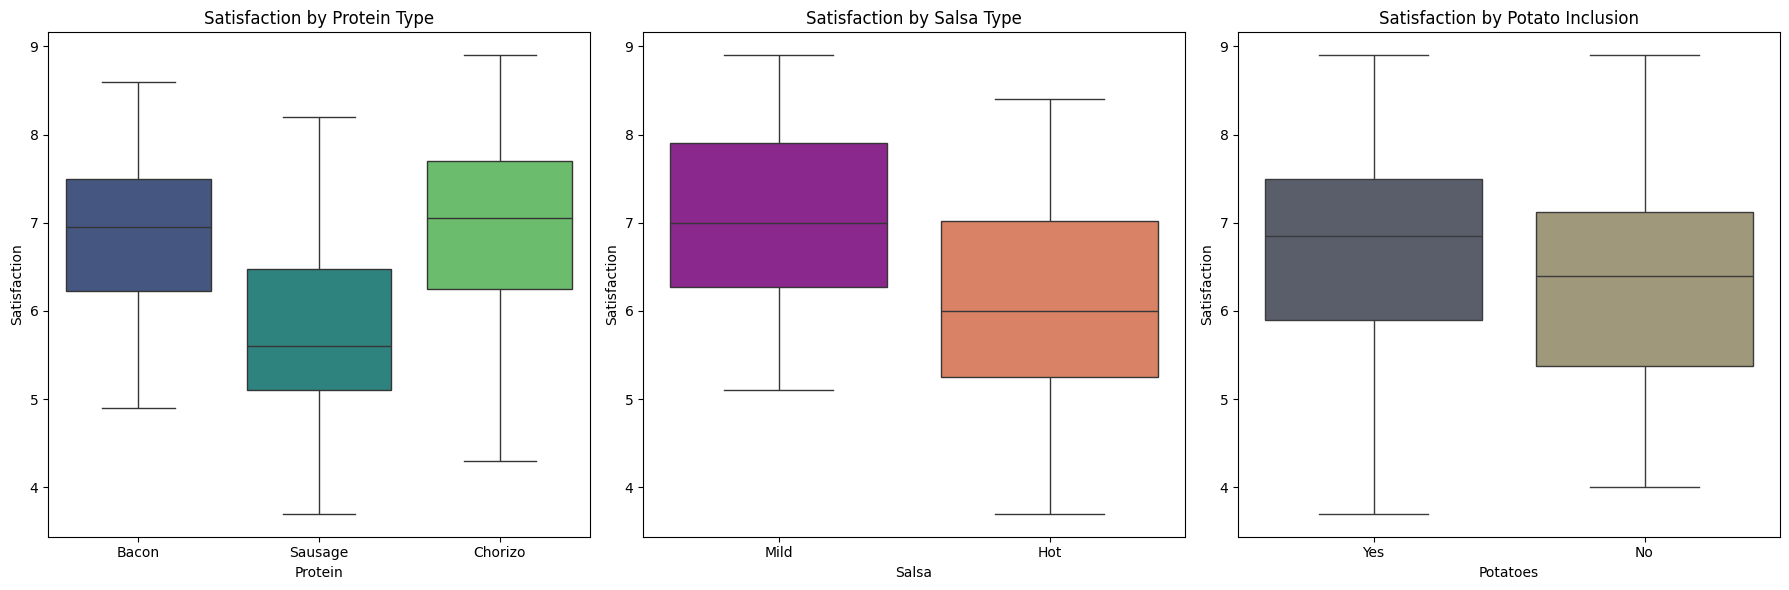

In [4]:
## Question 6 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

BB_data = pd.read_excel("Busters Burritos.xlsx")
BB_data

print("Question 6: Exploratory Data Analysis")
print(BB_data.columns.tolist())
print(BB_data.describe(include="all").T)

print(BB_data.info())
print(BB_data.head())
print(BB_data.min())
print(BB_data.max())

# Group-by summary for Protein
protein_summary = BB_data.groupby('Protein')['Satisfaction'].agg(['mean', 'std']).reset_index()
print("Satisfaction by Protein:")
display(protein_summary)

# Group-by summary for Salsa
salsa_summary = BB_data.groupby('Salsa')['Satisfaction'].agg(['mean', 'std']).reset_index()
print("\nSatisfaction by Salsa:")
display(salsa_summary)

# Group-by summary for Potatoes
potatoes_summary = BB_data.groupby('Potatoes')['Satisfaction'].agg(['mean', 'std']).reset_index()
print("\nSatisfaction by Potatoes:")
display(potatoes_summary)

#EDA BOXPLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Protein', y='Satisfaction', data=BB_data, ax=axes[0], palette='viridis')
axes[0].set_title('Satisfaction by Protein Type')

sns.boxplot(x='Salsa', y='Satisfaction', data=BB_data, ax=axes[1], palette='plasma')
axes[1].set_title('Satisfaction by Salsa Type')

sns.boxplot(x='Potatoes', y='Satisfaction', data=BB_data, ax=axes[2], palette='cividis')
axes[2].set_title('Satisfaction by Potato Inclusion')

plt.tight_layout()
plt.show()



7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

In [ ]:
## Question 7 Code ##

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [ ]:
## Question 9 Code ##

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [ ]:
## Question 10 Code ##

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [ ]:
## Question 11 Code ##

12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

2. Specify the outcome variable and how it is measured.

3. Specify the independent variables. What lurking variables may be present?

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [ ]:
## Question 6 Code ##

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

In [ ]:
## Question 8 Code ##

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

In [ ]:
## Question 9 Code ##

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 12 Code ##

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3. What is the difference between a fixed effect and a random effect?

4. What is the most important thing you learned in this class?